# Lung Cancer CT-Scan — Classification Pipeline

In [24]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Fix conflit OpenMP Windows

import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f"Device utilisé  : {DEVICE}")


PyTorch version : 2.10.0+cpu
CUDA disponible : False
Device utilisé  : cpu


## 1. Chargement & Inventaire des données

In [25]:
import kagglehub

dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
DATA_ROOT = Path(dataset_path) / "Data"

if not DATA_ROOT.exists():
    print(f"Le dossier {DATA_ROOT} n'existe pas.")
else:
    print(f"Dossier trouvé : {DATA_ROOT}")
    for split in ["train", "test", "valid"]:
        split_path = DATA_ROOT / split
        if split_path.exists():
            classes = sorted([d.name for d in split_path.iterdir() if d.is_dir()])
            print(f"   {split}/ → {len(classes)} classes : {classes}")



Dossier trouvé : C:\Users\desma\.cache\kagglehub\datasets\mohamedhanyyy\chest-ctscan-images\versions\1\Data
   train/ → 4 classes : ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
   test/ → 4 classes : ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
   valid/ → 4 classes : ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


## Chargement de  toute les images 

In [26]:
CLASS_NAMES  = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def get_class_from_folder(folder_name):
    """Mappe un nom de dossier (avec suffixe clinique éventuel) vers une classe."""
    for class_name in CLASS_NAMES:
        if folder_name == class_name or folder_name.startswith(class_name + '_'):
            return class_name
    return None

data_records = []
for split in ['train', 'valid', 'test']:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        continue
    for folder in sorted(split_dir.iterdir()):
        if not folder.is_dir():
            continue
        class_name = get_class_from_folder(folder.name)
        if class_name is None:
            continue
        for img_path in sorted(folder.glob('*.*')):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif']:
                data_records.append({
                    'path': str(img_path),
                    'split': split,
                    'class_name': class_name,
                    'label': CLASS_LABELS[class_name],
                    'filename': img_path.name
                })

df = pd.DataFrame(data_records)
print(f"Total images trouvées : {len(df)}\n")

pivot = df.pivot_table(index='class_name', columns='split', values='path', aggfunc='count', fill_value=0)
pivot['TOTAL'] = pivot.sum(axis=1)
pivot.loc['TOTAL'] = pivot.sum()
print("Distribution des images :")
print(pivot.to_string())

Total images trouvées : 1000

Distribution des images :
split                    test  train  valid  TOTAL
class_name                                        
adenocarcinoma            120    195     23    338
large.cell.carcinoma       51    115     21    187
normal                     54    148     13    215
squamous.cell.carcinoma    90    155     15    260
TOTAL                     315    613     72   1000


## selection de 5 images pour analyse avec 2 normal 

In [27]:
COLORS = ['#e74c3c', '#3498db', "#2e3330", '#f39c12', '#9b59b6']

sample_rows = []
for cls in CLASS_NAMES:
    row = df[(df['class_name'] == cls) & (df['split'] == 'train')].sample(1, random_state=SEED).iloc[0]
    sample_rows.append(row)
#2 normal
extra = df[(df['class_name'] == 'normal') & (df['split'] == 'train')].sample(1, random_state=SEED + 10).iloc[0]
sample_rows.append(extra)

samples = pd.DataFrame(sample_rows).reset_index(drop=True)

# analyse des dimensions
image_stats = []
for _, row in samples.iterrows():
    img = Image.open(row['path'])
    w, h = img.size
    image_stats.append({
        'class_name': row['class_name'],
        'width': w, 'height': h,
        'aspect_ratio': round(w / h, 2),
        'mode': img.mode,
        'file_size_kb': round(os.path.getsize(row['path']) / 1024, 1)
    })

stats_df = pd.DataFrame(image_stats)

print("📊 Dimensions des 5 images échantillon :\n")
print(stats_df[['class_name', 'width', 'height', 'aspect_ratio', 'mode', 'file_size_kb']].to_string(index=False))


📊 Dimensions des 5 images échantillon :

             class_name  width  height  aspect_ratio mode  file_size_kb
         adenocarcinoma    395     303          1.30 RGBA          99.9
   large.cell.carcinoma    388     248          1.56 RGBA          81.7
                 normal    800     577          1.39 RGBA         489.5
squamous.cell.carcinoma    367     194          1.89 RGBA          60.8
                 normal    731     555          1.32 RGBA         438.7


## Visualitaions des 5 images 

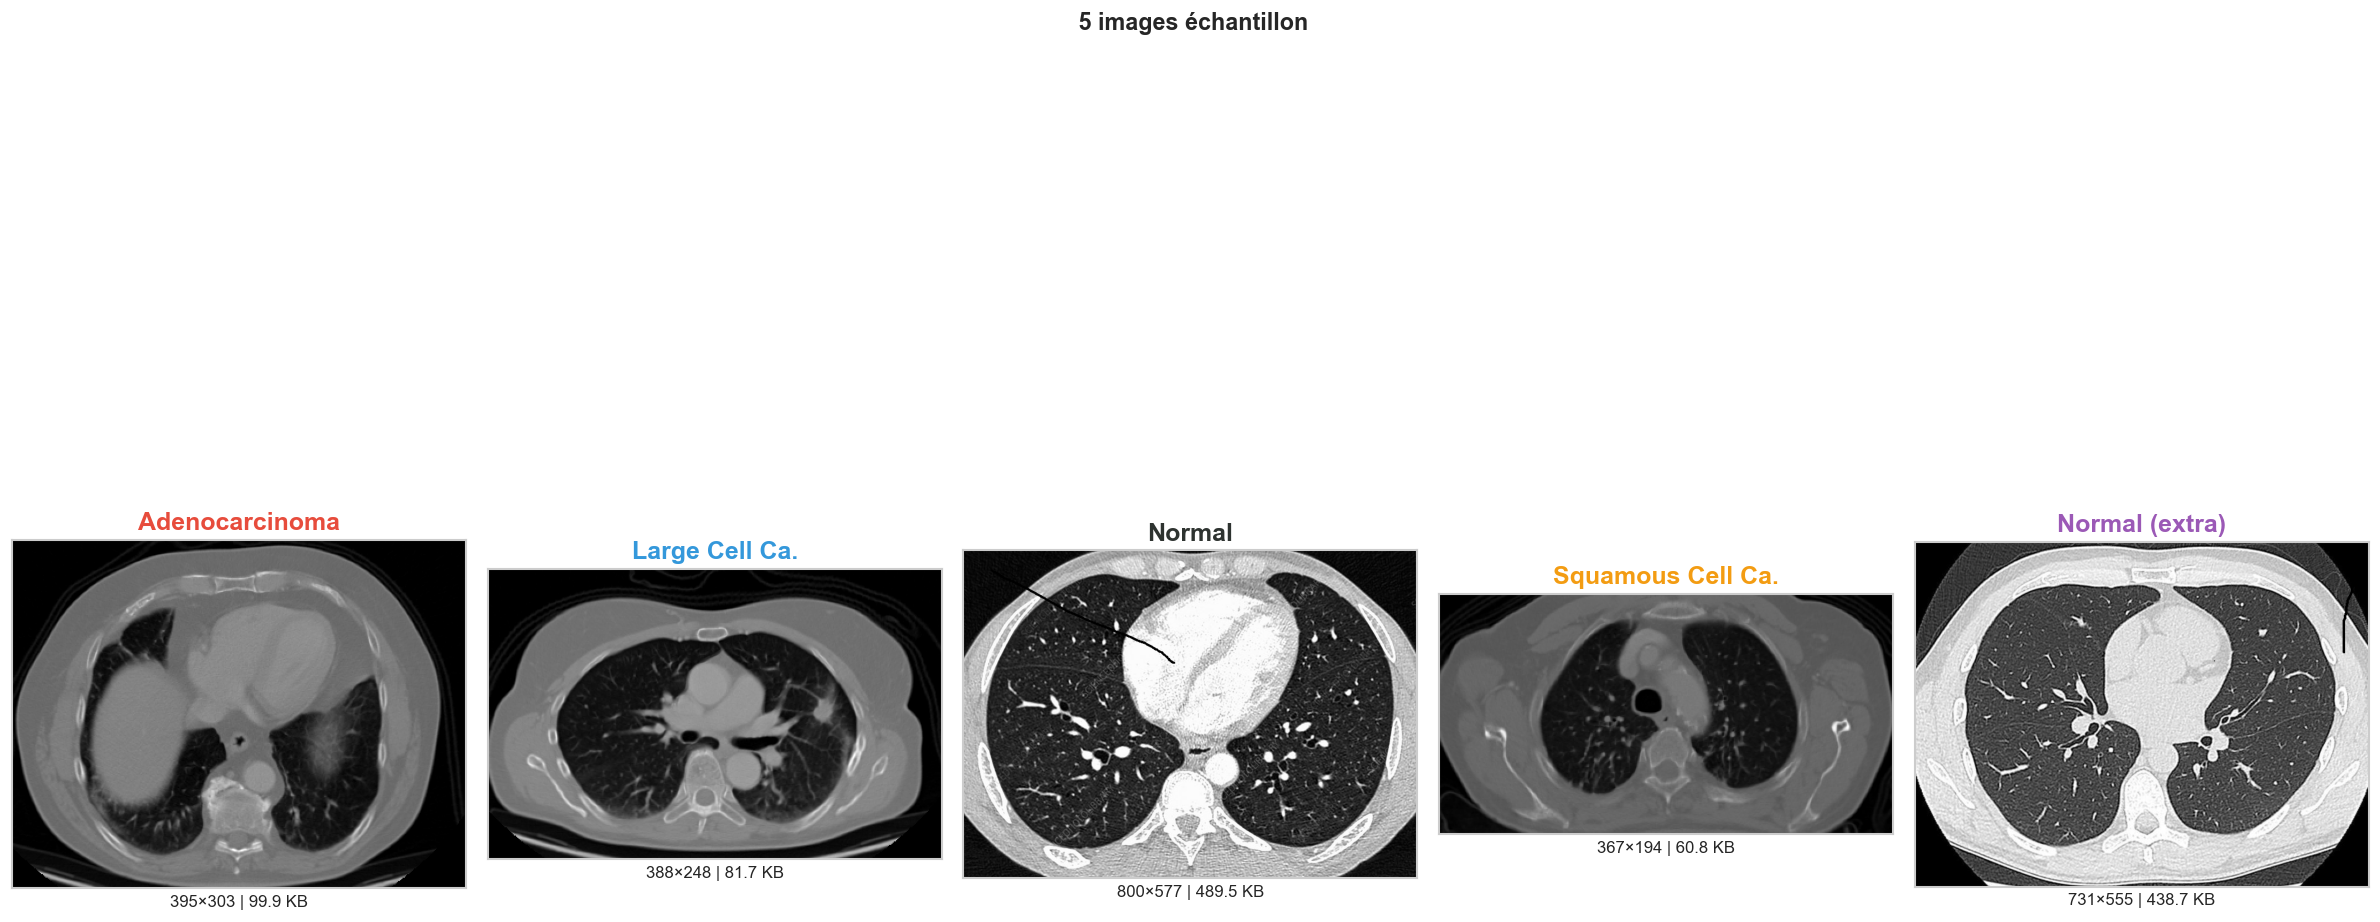

In [30]:
fig = plt.figure(figsize=(20, 8))
fig.suptitle(' 5 images échantillon', fontsize=14, fontweight='bold')

labels_vis = ['Adenocarcinoma', 'Large Cell Ca.', 'Normal', 'Squamous Cell Ca.', 'Normal (extra)']
for i, (_, row) in enumerate(samples.iterrows()):
    ax = fig.add_subplot(2, 5, 6 + i)
    img = Image.open(row['path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(labels_vis[i], fontsize=15, color=COLORS[i], fontweight='bold')
    w, h = img.size
    ax.set_xlabel(f"{w}×{h} | {image_stats[i]['file_size_kb']} KB", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('01_sample_analysis.png', dpi=400, bbox_inches='tight')
plt.show()

## Analyse des images pour l'ensemble du dataset 

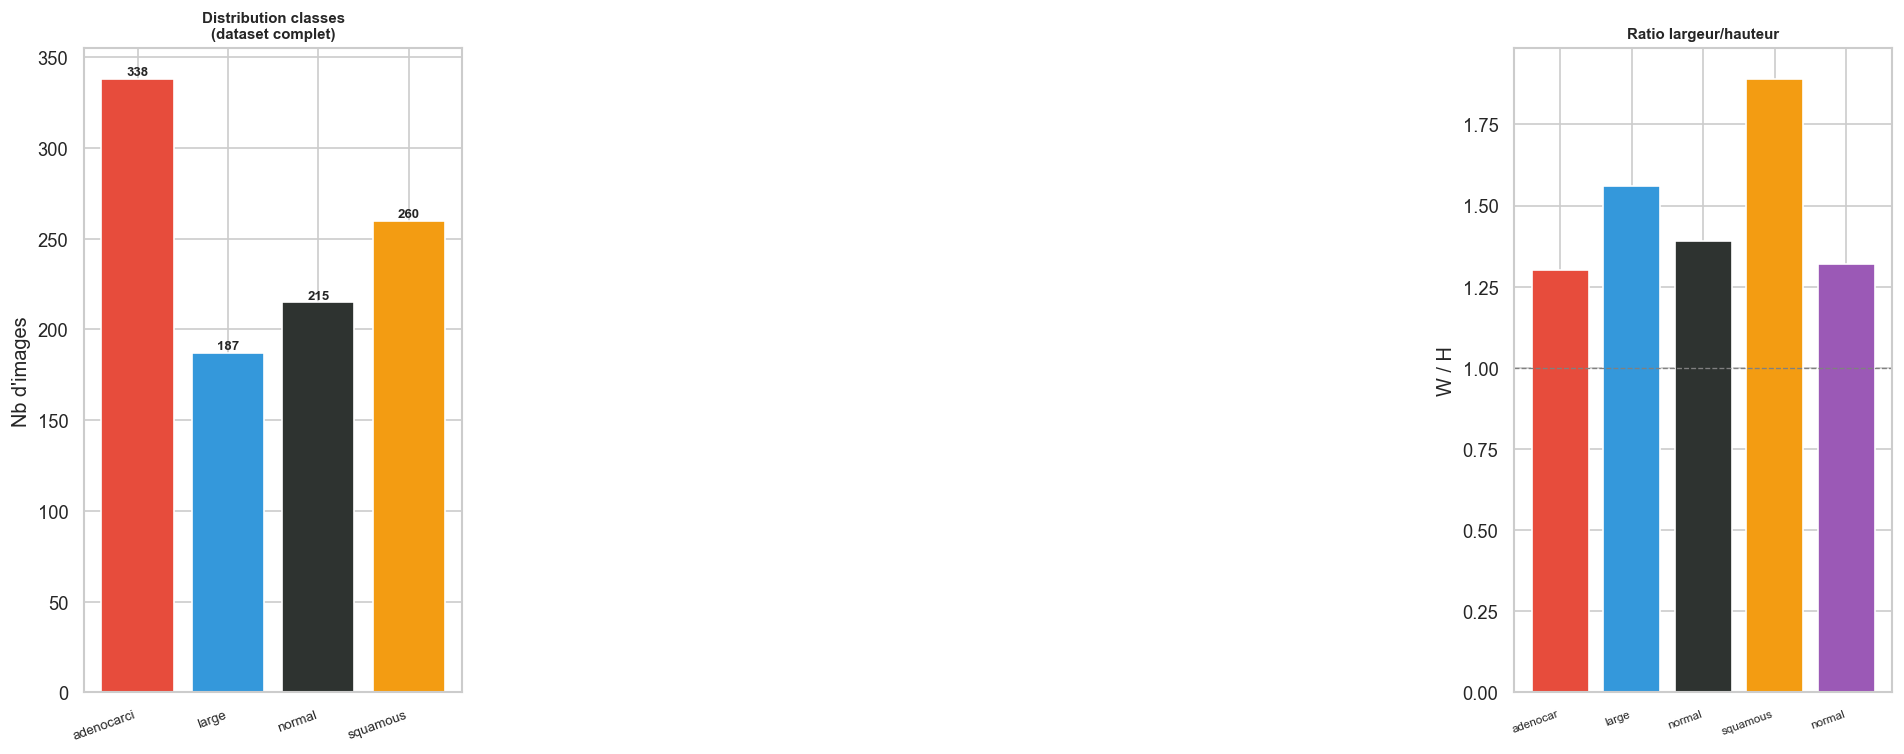

In [46]:
#Visu graphique et visuelle des 5 images échantillon

fig = plt.figure(figsize=(20, 12))


ax1 = fig.add_subplot(2, 5, 1)
class_counts = df['class_name'].value_counts().reindex(CLASS_NAMES)
bars = ax1.bar(range(len(CLASS_NAMES)), class_counts.values, color=COLORS)
ax1.set_xticks(range(len(CLASS_NAMES)))
ax1.set_xticklabels([c.split('.')[0][:10] for c in CLASS_NAMES], rotation=20, ha='right', fontsize=8)
ax1.set_title('Distribution classes\n(dataset complet)', fontweight='bold', fontsize=9)
ax1.set_ylabel("Nb d'images")
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', fontsize=8, fontweight='bold')


ax4 = fig.add_subplot(2, 5, 4)
ax4.bar(range(5), stats_df['aspect_ratio'], color=COLORS)
ax4.axhline(1.0, color='gray', linestyle='--', lw=0.8)
ax4.set_xticks(range(5))
ax4.set_xticklabels([s[:8] for s in stats_df['class_name'].str.split('.').str[0]], rotation=20, ha='right', fontsize=7)
ax4.set_ylabel('W / H'); ax4.set_title('Ratio largeur/hauteur', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('01_sample_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

